# Neural network classifier

___

## Data onboarding and preprocessing

### Load data

In [11]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.typing import NDArray
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from typing import List, Optional, Callable 
import pickle
from sklearn.preprocessing import StandardScaler

# Import custom neural network implementation
from neural_network import *

figs_dir = "figures"

np.random.seed(42)

dir_path = "../training_data"

names, labels, samples = [], [], []
for label in range(10): 
    for file_path in [os.path.join(dir_path, f) for f in os.listdir(dir_path) if ".csv" in f and f"stroke_{label}" in f]: 
        names.append(os.path.splitext(os.path.basename(file_path))[0])
        labels.append(label)
        samples.append(pd.read_csv(file_path, header=None))

### Preprocess the data

Preprocess the samples and convert labels to numpy array

In [12]:
from NN_preprocessing import *

# Define interpolation target length and image size
target_len = max([len(s) for s in samples])
target_len = 256
print(target_len)
img_size = (28, 28)

# Preprocess samples
# Parameters: sample, use_interpolation, use_PCA, use_convert_to_image, use_flatten, target_len, img_size
# X = np.array([preprocess(s, True, False, False, True, target_len, img_size) for s in samples])

#X_scaled = []
# for x in X: 
#     x_scaled = (x - np.mean(x, axis=0)) / np.max(np.abs(x)) 
#     X_scaled.append(x_scaled)
#X = [StandardScaler().fit_transform(np.array(s)) for s in X_scaled]

X = [resample(np.array(s), target_len) for s in samples]
# X = [project_to_2d(s) for s in X]
X = [min_max_scale(x) for x in X]
X = np.array([s.flatten() for s in X])
print(X.shape)

256
(1000, 768)


One hot encode y: 

In [13]:
# Convert labels to a numpy array
y = np.array(labels)

___

## Training the model 

### Train the model 

In [14]:
uniform = np.random.uniform

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 1000, 16, 0.1, 1e-3, 1e-6
criterion = CategoricalCrossEntropySoftmax()
n_splits = 5 # Number of splits for k-fold cross-validation

# Prepare a list for results
results = []

# One-hot encode y
y_encoded = one_hot_encode(y, np.arange(10))

# Train the model using k-fold cross-validation
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
for i, (train_idx, test_idx) in enumerate(kf.split(X, y)):

    # Split the data to training and test sets
    X_train, X_test, y_train, y_test = X[train_idx], X[test_idx], y_encoded[train_idx], y_encoded[test_idx]

    # Initialize a new model 
    model = NeuralNetworkClassifier(
        Dense(uniform(-0.1, 0.1, size=(X.shape[1], 512)), np.zeros(512), ReLU),
        Dense(uniform(-0.1, 0.1, size=(512, 256)), np.zeros(256), ReLU), 
        Dense(uniform(-0.1, 0.1, size=(256, 128)), np.zeros(128), ReLU), 
        Dense(uniform(-0.1, 0.1, size=(128, 10)), np.zeros(10), Softmax)
    )
    
    # Train the model  
    loss_history, accuracy_history = train(model, X_train, y_train, X_val=X_test, y_val=y_test,
        criterion=criterion, max_iter=epochs, batch_size=batch_size, learning_rate=learning_rate, 
        tol=tol, min_loss=min_loss, verbose=True
    )

    # Measure accuracy on the training set
    y_pred = model.forward(X_train)
    accuracy_train = accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_pred, axis=1))

    # Measure accuracy on the test set
    y_pred = model.forward(X_test)
    accuracy_test = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1))

    # Measure accuracy on the complete dataset
    y_pred = model.forward(X)
    accuracy_all = accuracy_score(np.argmax(y_encoded, axis=1), np.argmax(y_pred, axis=1))

    # Record results
    results.append({
        "loss_history":loss_history,
        "accuracy_history":accuracy_history,
        "accuracy_train":accuracy_train,
        "accuracy_test":accuracy_test,
        "accuracy_all":accuracy_all,
        "model": model, 
        "train_idx": train_idx,
        "test_idx": test_idx
    })

  1%|▏         | 14/1000 [00:02<02:22,  6.91it/s]


Visualize results

Model accuracy; training set: 98.38 %, test set: 98.00 %, complete set: 98.30 %
Model accuracy; training set: 98.50 %, test set: 96.00 %, complete set: 98.00 %
Model accuracy; training set: 97.50 %, test set: 95.00 %, complete set: 97.00 %
Model accuracy; training set: 98.25 %, test set: 96.00 %, complete set: 97.80 %
Model accuracy; training set: 98.12 %, test set: 95.50 %, complete set: 97.60 %
Mean model accuracy; training set: 98.15 %, test set: 96.10 %, complete set: 97.74 %


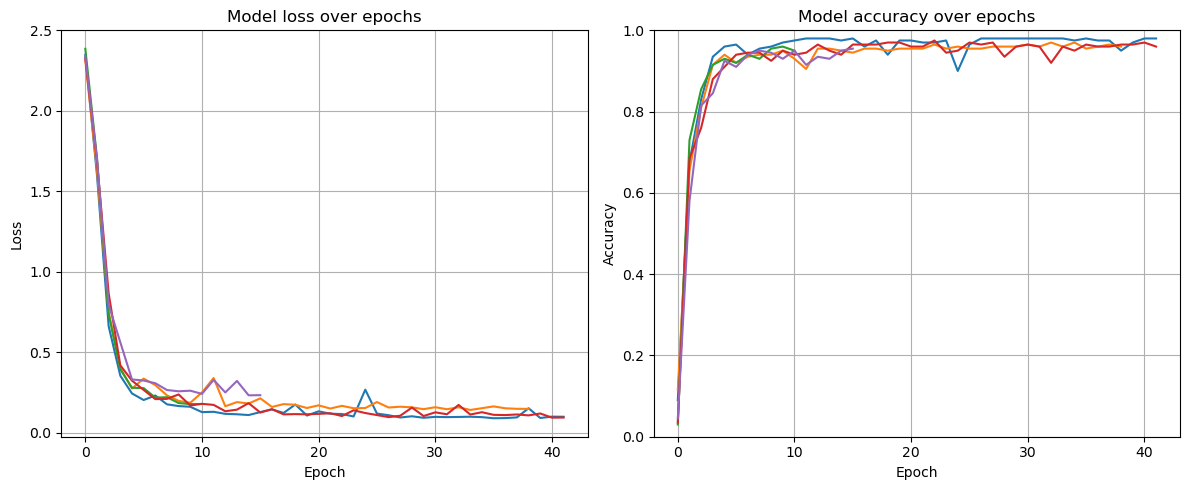

In [15]:
# Visualize training and validation loss
plt.figure(figsize=(12, 5))
for i, result in enumerate(results): 

    loss_history = result["loss_history"]
    accuracy_history = result["accuracy_history"]
    accuracy_train = result["accuracy_train"]
    accuracy_test = result["accuracy_test"]
    accuracy_all = result["accuracy_all"]

    # Visualize training loss
    plt.subplot(1, 2, 1)
    plt.plot(loss_history)
    plt.title("Model loss over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()

    # Visualize validation accuracy
    ax = plt.subplot(1, 2, 2)
    ax.set_ylim([0, 1])
    plt.grid()
    plt.plot(accuracy_history)
    plt.title("Model accuracy over epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    # Measured final accuracy
    print(f"Model accuracy; training set: {accuracy_train*100:.2f} %", 
          f"test set: {accuracy_test*100:.2f} %",
          f"complete set: {accuracy_all*100:.2f} %", sep=", "
    )

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, "NN_training_eval_kfold.png"))

# Calculate combined statistics
mean_train_accuracy = np.mean([r["accuracy_train"] for r in results])
mean_test_accuracy = np.mean([r["accuracy_test"] for r in results])
mean_accuracy_all = np.mean([r["accuracy_all"] for r in results])
print(f"Mean model accuracy; training set: {mean_train_accuracy*100:.2f} %", 
      f"test set: {mean_test_accuracy*100:.2f} %", 
      f"complete set: {mean_accuracy_all*100:.2f} %", sep=", "
)

plt.show()

#### Choose and visualize the best model 

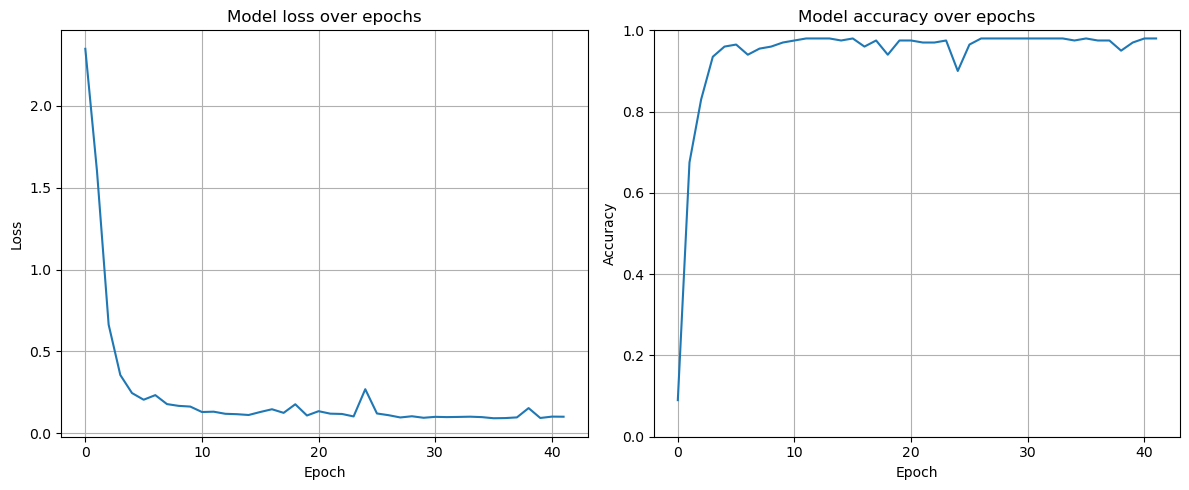

Model accuracy. Training set: 98.38 %, test set: 98.00 %


In [16]:
# Choose the best model 
best_result = results[np.argmin(r['accuracy_test'] for r in results)]
loss_history = best_result["loss_history"]
accuracy_history = best_result["accuracy_history"]
accuracy_train = best_result["accuracy_train"]
accuracy_test = best_result["accuracy_test"]
model = best_result['model']
train_idx, test_idx = best_result['train_idx'], best_result['test_idx']

# Training parameters
epochs, batch_size, learning_rate, tol, min_loss = 10000, 16, 0.1, 1e-3, 1e-8
criterion = CategoricalCrossEntropySoftmax()

# Visualize training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Model loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# Visualize validation accuracy
ax = plt.subplot(1, 2, 2)
ax.set_ylim([0, 1])
plt.grid()
plt.plot(accuracy_history)
plt.title("Model accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, "NN_training_eval.png"))
plt.show()

# Measured accuracy
print(f"Model accuracy. Training set: {accuracy_train*100:.2f} %, test set: {accuracy_test*100:.2f} %")

Visualize model performance using a confusion matrix

98.0 %


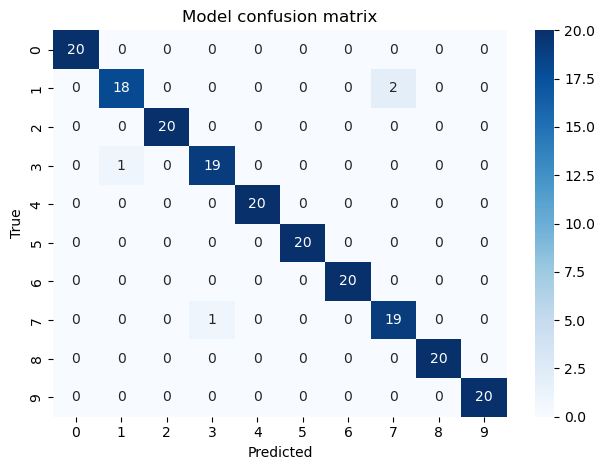

In [17]:
X_test, y_test = X[test_idx], y[test_idx]
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred)*100, "%")

confusion_matrix = np.zeros((10, 10), dtype=int)

for i, j in zip(y_test, y_pred): 
    confusion_matrix[i, j] += 1

sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title("Model confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(figs_dir, "NN_confusion_matrix.png"))
plt.show()

#### Store the trained model 

In [18]:
trained_models_dir = os.path.join("..", "trained_models")
model_path = os.path.join(trained_models_dir, "NN_classifier.pkl")

with open(model_path, "wb") as f: pickle.dump(model, f)

___

## Combining the preprocessing pipeline and NN classifier to a single function

In [19]:
def preprocess_samples(samples: List[NDArray|pd.DataFrame]) -> NDArray: 
    target_len = max([len(s) for s in samples])
    X = np.array([preprocess(s, target_len=target_len, img_size=img_size) for s in samples])
    return X

def classify(samples: List[NDArray|pd.DataFrame], predict: Callable, preprocess: Callable) -> NDArray: 

    # Preprocess the samples
    X = preprocess(samples)
    
    # Predict the classes of the samples
    return predict(X)

In [20]:
from NN_preprocessing import NN_preprocess_samples

# Select random test set (NOTE: this is from the entire dataset)
index = np.random.choice(len(samples), 100).astype(int)
test_datas, test_labels = [samples[i] for i in index], [labels[i] for i in index]

preprocess = lambda s : NN_preprocess_samples(s, target_len=256)

# Predict the test set using the classify-function
predicted_labels = classify(test_datas, model.predict, preprocess)

# Measure prediction accuracy
print(f"Classification accuracy: {accuracy_score(test_labels, predicted_labels)*100:.0f} %")

Classification accuracy: 98 %
